# COLAB COMPLETO - REENTRENAMIENTO MINIRESNET PARA SIRENAS
# Dataset: UrbanSound8K
# Modelo base: miniresnetv1_s1_64x50_tl.keras
# Entrada: log-Mel 64 x 50 x 1
# Salida: binaria, siren / non_siren

1. INSTALACIÓN E IMPORTACIÓN DE LIBRERÍAS

In [ ]:
# Instalación opcional de dependencias en el entorno de Colab.
# !pip install -q librosa soundfile scikit-learn

import os
import json
import math
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

print("TensorFlow:", tf.__version__)
print("Librosa:", librosa.__version__)
print("NumPy:", np.__version__)

TensorFlow: 2.20.0
Librosa: 0.11.0
NumPy: 2.0.2


2. MONTAJE DE GOOGLE DRIVE

In [2]:
from google.colab import drive

MOUNT_DRIVE = True

if MOUNT_DRIVE:
    drive.mount("/content/drive")

Mounted at /content/drive


3. CONFIGURACIÓN GENERAL

In [4]:
# Carpeta raíz del proyecto en Google Drive.
PROJECT_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren")

# Modelo base Keras.
MODEL_FILENAME = "miniresnetv1_s1_64x50_tl.keras"
MODEL_PATH = PROJECT_ROOT / MODEL_FILENAME

# UrbanSound8K debe estar descomprimido dentro de PROJECT_ROOT.
# Estructura esperada:
#
# PROJECT_ROOT/
#   miniresnetv1_s1_64x50_tl.keras
#   UrbanSound8K/
#       audio/
#           fold1/
#           fold2/
#           ...
#           fold10/
#       metadata/
#           UrbanSound8K.csv
#
URBANSOUND_ROOT = PROJECT_ROOT / "UrbanSound8K"
URBANSOUND_CSV_PATH = URBANSOUND_ROOT / "metadata" / "UrbanSound8K.csv"
AUDIO_ROOT = URBANSOUND_ROOT / "audio"

# Carpetas de trabajo/resultados.
WORK_DIR = Path("/content/miniresnet_siren_training")
RESULTS_DIR = WORK_DIR / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
EXPORT_DIR = RESULTS_DIR / "exported_inputs"
MODELS_DIR = RESULTS_DIR / "models"
CACHE_DIR = WORK_DIR / "feature_cache"

for d in [WORK_DIR, RESULTS_DIR, FIGURES_DIR, EXPORT_DIR, MODELS_DIR, CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ============================================================
# Parámetros de audio/preprocesado utilizados en la evaluación previa
# ============================================================

SAMPLE_RATE = 16000
AUDIO_DURATION = 1.0
N_SAMPLES = int(SAMPLE_RATE * AUDIO_DURATION)

FRAME_SIZE = 1024
HOP_SIZE = 320
N_FFT = 1024
N_MELS = 64
TARGET_FRAMES = 50
TOP_DB = 80.0

FMIN = 0
FMAX = SAMPLE_RATE / 2

# Configuración de centrado de la STFT utilizada en el preprocesado.
STFT_CENTER = True

# Conversión dB.
USE_GLOBAL_DB_REFERENCE = False
GLOBAL_POWER_REFERENCE = None

# Estrategia de uso de clips.
# El modelo acepta 1 s. UrbanSound8K tiene clips de hasta 4 s.
# "full_clip_windows": divide cada clip en ventanas de 1 s no solapadas.
# "first_second": usa solo el primer segundo.
TRAIN_STRATEGY = "full_clip_windows"
EVAL_STRATEGY = "full_clip_mean"

# Clases binarias.
CLASS_NAMES = ["non_siren", "siren"]
CLASS_TO_INDEX = {"non_siren": 0, "siren": 1}
INDEX_TO_CLASS = {0: "non_siren", 1: "siren"}

# Entrenamiento.
BATCH_SIZE = 32
EPOCHS_HEAD = 30
EPOCHS_FINE = 20
LEARNING_RATE_HEAD = 1e-4
LEARNING_RATE_FINE = 1e-5
PATIENCE = 7

# Para pruebas rápidas.
FAST_DEBUG = False
FAST_DEBUG_MAX_FILES = 300

# Ejecutar todos los folds.
RUN_KFOLD = True

# Entrenar modelo final usando todos los datos.
RUN_FINAL_TRAINING = True

# Umbral de decisión.
DEFAULT_THRESHOLD = 0.5

print("PROJECT_ROOT:", PROJECT_ROOT)
print("MODEL_PATH:", MODEL_PATH)
print("URBANSOUND_CSV_PATH:", URBANSOUND_CSV_PATH)
print("AUDIO_ROOT:", AUDIO_ROOT)

print("\nInput expected:", (N_MELS, TARGET_FRAMES, 1))
print("Classes:", CLASS_NAMES)

PROJECT_ROOT: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren
MODEL_PATH: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/miniresnetv1_s1_64x50_tl.keras
URBANSOUND_CSV_PATH: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/UrbanSound8K/metadata/UrbanSound8K.csv
AUDIO_ROOT: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/UrbanSound8K/audio

Input expected: (64, 50, 1)
Classes: ['non_siren', 'siren']


4. COMPROBACIÓN DE RUTAS

In [ ]:
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"No encuentro el modelo base: {MODEL_PATH}")

if not URBANSOUND_CSV_PATH.exists():
    raise FileNotFoundError(f"No encuentro el CSV de UrbanSound8K: {URBANSOUND_CSV_PATH}")

if not AUDIO_ROOT.exists():
    raise FileNotFoundError(f"No encuentro la carpeta de audio: {AUDIO_ROOT}")

print("Rutas comprobadas correctamente.")

Rutas comprobadas correctamente.


 5. CARGA DEL MODELO BASE

In [ ]:
base_check_model = tf.keras.models.load_model(MODEL_PATH, compile=False)

print("Modelo base cargado desde:", MODEL_PATH)
print("Input shape:", base_check_model.input_shape)
print("Output shape:", base_check_model.output_shape)

expected_input_shape = (None, N_MELS, TARGET_FRAMES, 1)
actual_input_shape = tuple(base_check_model.input_shape)

if actual_input_shape[1:] != (N_MELS, TARGET_FRAMES, 1):
    print("\nWARNING: la forma de entrada del modelo no coincide exactamente con (64, 50, 1).")
    print("Esperado:", (N_MELS, TARGET_FRAMES, 1))
    print("Actual:", actual_input_shape[1:])

base_check_model.summary()

Modelo base cargado desde: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/miniresnetv1_s1_64x50_tl.keras
Input shape: (None, 64, 50, 1)
Output shape: (None, 10)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_1             │ (None, 64, 50, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 70, 56, 1) │          0 │ input_1[0][0]     │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 32, 25,    │      3,200 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 32, 25,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 32, 25,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 34, 27,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 16, 13,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 8, 7, 64)  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 8, 7, 64)  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 8, 7, 64)  │          0 │ conv2_block1_1_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 8, 7, 64)  │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 8, 7, 64)  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 8, 7, 64)  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 8, 7, 64)  │        256 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 8, 7, 64)  │          0 │ conv2_block1_2_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_add    │ (None, 8, 7, 64)  │          0 │ conv2_block1_0_b… │
│ (Add)               │                   │            │ conv2_block1_2_r… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 8, 7, 64)  │          0 │ conv2_block1_add

 Total params: 126,922 (495.79 KB)

 Trainable params: 35,850 (140.04 KB)

 Non-trainable params: 91,072 (355.75 KB)

6. CARGA Y PREPARACIÓN DE URBANSOUND8K

In [ ]:
metadata = pd.read_csv(URBANSOUND_CSV_PATH)

required_cols = ["slice_file_name", "fold", "class", "classID"]
missing = [c for c in required_cols if c not in metadata.columns]
if missing:
    raise ValueError(f"Faltan columnas esperadas en UrbanSound8K.csv: {missing}")

metadata["filepath"] = metadata.apply(
    lambda row: AUDIO_ROOT / f"fold{int(row['fold'])}" / row["slice_file_name"],
    axis=1
)

metadata["label_index"] = metadata["class"].apply(lambda x: 1 if x == "siren" else 0)
metadata["label_name"] = metadata["label_index"].map(INDEX_TO_CLASS)

metadata["exists"] = metadata["filepath"].apply(lambda p: Path(p).exists())

missing_files = metadata[~metadata["exists"]]

if len(missing_files) > 0:
    print("WARNING: hay archivos de audio que no se han encontrado.")
    display(missing_files.head())
    raise FileNotFoundError("Hay archivos de audio ausentes en la ruta configurada mediante AUDIO_ROOT.")

metadata = metadata.drop(columns=["exists"]).reset_index(drop=True)

if FAST_DEBUG:
    metadata = metadata.sample(
        n=min(FAST_DEBUG_MAX_FILES, len(metadata)),
        random_state=42
    ).reset_index(drop=True)

print("Número total de clips:", len(metadata))

print("\nDistribución original de clases UrbanSound8K:")
display(metadata["class"].value_counts())

print("\nDistribución binaria:")
display(metadata["label_name"].value_counts())

print("\nDistribución por fold y clase binaria:")
display(metadata.groupby(["fold", "label_name"]).size().unstack(fill_value=0))

display(metadata.head())


Número total de clips: 8732

Distribución original de clases UrbanSound8K:


,count
class,
dog_bark,1000
children_playing,1000
air_conditioner,1000
street_music,1000
jackhammer,1000
engine_idling,1000
drilling,1000
siren,929
car_horn,429



Distribución binaria:


,count
label_name,
non_siren,7803
siren,929



Distribución por fold y clase binaria:


label_name,non_siren,siren
fold,,
1,787,86
2,797,91
3,806,119
4,824,166
5,865,71
6,749,74
7,761,77
8,726,80
9,734,82


,slice_file_name,fsID,start,end,salience,fold,classID,class,filepath,label_index,label_name
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark,/content/drive/MyDrive/Colab Notebooks/TFM/Ver...,0,non_siren
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing,/content/drive/MyDrive/Colab Notebooks/TFM/Ver...,0,non_siren
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing,/content/drive/MyDrive/Colab Notebooks/TFM/Ver...,0,non_siren
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing,/content/drive/MyDrive/Colab Notebooks/TFM/Ver...,0,non_siren
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing,/content/drive/MyDrive/Colab Notebooks/TFM/Ver...,0,non_siren


 7. FUNCIONES DE PREPROCESADO LOG-MEL

In [ ]:
def load_audio_mono(path, sample_rate=SAMPLE_RATE):
    """Carga audio mono remuestreado a sample_rate."""
    y, sr = librosa.load(str(path), sr=sample_rate, mono=True)
    return y.astype(np.float32), sr


def fix_audio_length(y, n_samples=N_SAMPLES):
    """Recorta o rellena con ceros hasta n_samples."""
    if len(y) < n_samples:
        y = np.pad(y, (0, n_samples - len(y)), mode="constant")
    else:
        y = y[:n_samples]
    return y.astype(np.float32)


def split_audio_into_windows(y, n_samples=N_SAMPLES, hop_samples=None):
    """Divide un clip en ventanas de 1 segundo."""
    if hop_samples is None:
        hop_samples = n_samples

    if len(y) < n_samples:
        return [fix_audio_length(y, n_samples)]

    windows = []

    for start in range(0, len(y) - n_samples + 1, hop_samples):
        windows.append(y[start:start + n_samples].astype(np.float32))

    if not windows:
        windows = [fix_audio_length(y, n_samples)]

    return windows


def compute_mel_power(y):
    """Calcula espectrograma Mel de potencia."""
    mel_power = librosa.feature.melspectrogram(
        y=y,
        sr=SAMPLE_RATE,
        n_fft=N_FFT,
        hop_length=HOP_SIZE,
        win_length=FRAME_SIZE,
        window="hann",
        center=STFT_CENTER,
        power=2.0,
        n_mels=N_MELS,
        fmin=FMIN,
        fmax=FMAX,
        htk=False,
        norm="slaney",
    )
    return mel_power.astype(np.float32)


def power_to_db_global(mel_power, ref_power=None, top_db=TOP_DB):
    """Conversión potencia Mel -> dB."""
    if ref_power is None:
        logmel_db = librosa.power_to_db(
            mel_power,
            ref=np.max,
            top_db=top_db
        )
    else:
        logmel_db = librosa.power_to_db(
            mel_power,
            ref=float(ref_power),
            top_db=top_db
        )

    return logmel_db.astype(np.float32)


def pad_or_crop_time_frames(logmel, target_frames=TARGET_FRAMES):
    """Ajusta el eje temporal a TARGET_FRAMES."""
    n_mels, n_frames = logmel.shape

    if n_mels != N_MELS:
        raise ValueError(f"Número de bandas Mel incorrecto: {n_mels}, esperado {N_MELS}")

    if n_frames < target_frames:
        pad_width = target_frames - n_frames
        logmel = np.pad(
            logmel,
            ((0, 0), (0, pad_width)),
            mode="constant",
            constant_values=0.0
        )
    elif n_frames > target_frames:
        logmel = logmel[:, :target_frames]

    return logmel.astype(np.float32)


def preprocess_audio_array_to_logmel(y, global_power_reference=None, return_intermediate=False):
    """Preprocesa array de audio mono de 1 segundo a tensor (1, 64, 50, 1)."""
    y = fix_audio_length(y, N_SAMPLES)

    mel_power = compute_mel_power(y)

    ref = global_power_reference if USE_GLOBAL_DB_REFERENCE else None
    logmel_db = power_to_db_global(
        mel_power,
        ref_power=ref,
        top_db=TOP_DB
    )

    real_frames = logmel_db.shape[1]
    logmel_fixed = pad_or_crop_time_frames(logmel_db, TARGET_FRAMES)

    tensor = logmel_fixed.astype(np.float32)[np.newaxis, :, :, np.newaxis]

    if return_intermediate:
        return tensor, {
            "audio": y,
            "mel_power": mel_power,
            "logmel_db_before_frame_fix": logmel_db,
            "real_frames": real_frames,
            "logmel_fixed": logmel_fixed,
        }

    return tensor


def preprocess_audio_to_logmel(path, global_power_reference=None, return_intermediate=False):
    y, sr = load_audio_mono(path, SAMPLE_RATE)
    y_1s = fix_audio_length(y, N_SAMPLES)

    return preprocess_audio_array_to_logmel(
        y_1s,
        global_power_reference=global_power_reference,
        return_intermediate=return_intermediate,
    )


# Comprobación de frames reales.
test_y = np.zeros(N_SAMPLES, dtype=np.float32)
test_mel = compute_mel_power(test_y)

print("Forma Mel power antes de ajustar:", test_mel.shape)
print("Frames reales antes de padding/cropping:", test_mel.shape[1])
print("Forma final esperada:", (1, N_MELS, TARGET_FRAMES, 1))

Forma Mel power antes de ajustar: (64, 51)
Frames reales antes de padding/cropping: 51
Forma final esperada: (1, 64, 50, 1)


8. VISUALIZACIÓN DE UNA MUESTRA

Ejemplo: 100032-3-0-0.wav
Clase original: dog_bark
Clase binaria: non_siren
Tensor shape: (1, 64, 50, 1)
Frames reales antes de ajuste: 51


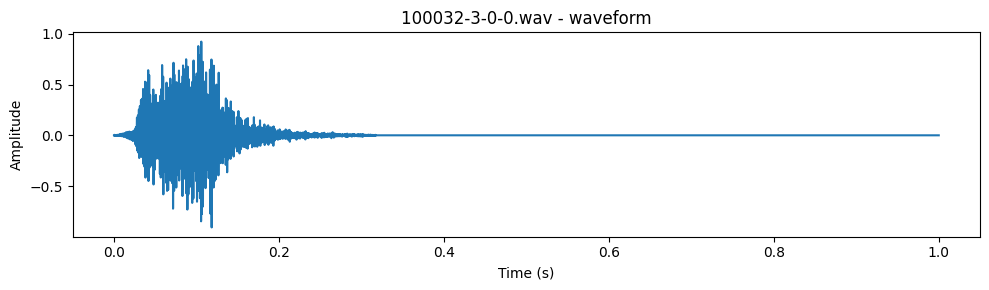

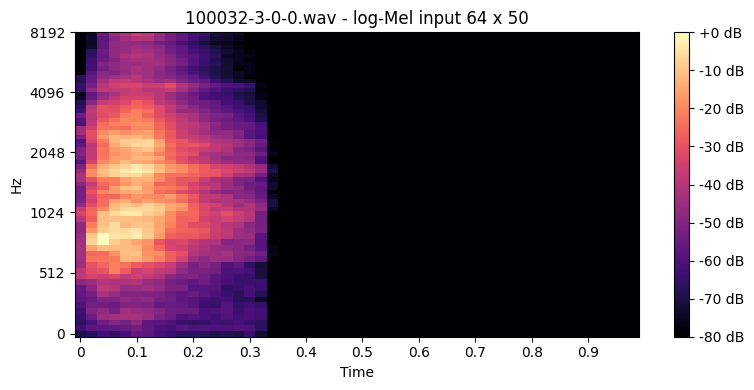

In [ ]:
def plot_waveform_and_logmel(audio, logmel_fixed, title_prefix="Example"):
    plt.figure(figsize=(10, 3))
    t = np.arange(len(audio)) / SAMPLE_RATE
    plt.plot(t, audio)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(f"{title_prefix} - waveform")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    librosa.display.specshow(
        logmel_fixed,
        sr=SAMPLE_RATE,
        hop_length=HOP_SIZE,
        x_axis="time",
        y_axis="mel",
        fmin=FMIN,
        fmax=FMAX,
    )
    plt.colorbar(format="%+2.0f dB")
    plt.title(f"{title_prefix} - log-Mel input 64 x 50")
    plt.tight_layout()
    plt.show()


example_row = metadata.iloc[0]
example_tensor, example_info = preprocess_audio_to_logmel(
    example_row["filepath"],
    return_intermediate=True
)

print("Ejemplo:", example_row["slice_file_name"])
print("Clase original:", example_row["class"])
print("Clase binaria:", example_row["label_name"])
print("Tensor shape:", example_tensor.shape)
print("Frames reales antes de ajuste:", example_info["real_frames"])

plot_waveform_and_logmel(
    example_info["audio"],
    example_info["logmel_fixed"],
    title_prefix=example_row["slice_file_name"]
)

9. PRECOMPUTAR FEATURES

In [ ]:
def build_feature_dataset(metadata_df, strategy=TRAIN_STRATEGY):
    X_list = []
    y_list = []
    fold_list = []
    file_list = []
    class_list = []
    window_index_list = []

    for i, row in metadata_df.iterrows():
        path = row["filepath"]
        label = int(row["label_index"])
        fold = int(row["fold"])
        original_class = row["class"]
        filename = row["slice_file_name"]

        y_audio, _ = load_audio_mono(path, SAMPLE_RATE)

        if strategy == "first_second":
            windows = [fix_audio_length(y_audio, N_SAMPLES)]
        elif strategy == "full_clip_windows":
            windows = split_audio_into_windows(
                y_audio,
                n_samples=N_SAMPLES,
                hop_samples=N_SAMPLES
            )
        else:
            raise ValueError(f"Estrategia no soportada: {strategy}")

        for w_idx, w in enumerate(windows):
            tensor = preprocess_audio_array_to_logmel(
                w,
                global_power_reference=GLOBAL_POWER_REFERENCE,
                return_intermediate=False
            )

            # tensor: (1, 64, 50, 1) -> x: (64, 50, 1)
            x = tensor[0]

            X_list.append(x)
            y_list.append(label)
            fold_list.append(fold)
            file_list.append(filename)
            class_list.append(original_class)
            window_index_list.append(w_idx)

        if (i + 1) % 250 == 0:
            print(f"Procesados {i + 1}/{len(metadata_df)} clips")

    X = np.stack(X_list, axis=0).astype(np.float32)
    y = np.array(y_list, dtype=np.float32)
    folds = np.array(fold_list, dtype=np.int32)

    windows_df = pd.DataFrame({
        "filename": file_list,
        "original_class": class_list,
        "label_index": y.astype(int),
        "label_name": [INDEX_TO_CLASS[int(v)] for v in y],
        "fold": folds,
        "window_index": window_index_list,
    })

    return X, y, folds, windows_df


FEATURE_CACHE_X = CACHE_DIR / "X_logmel_64x50.npy"
FEATURE_CACHE_Y = CACHE_DIR / "y_binary.npy"
FEATURE_CACHE_FOLDS = CACHE_DIR / "folds.npy"
FEATURE_CACHE_DF = CACHE_DIR / "windows_metadata.csv"

REBUILD_FEATURE_CACHE = False

if (
    FEATURE_CACHE_X.exists()
    and FEATURE_CACHE_Y.exists()
    and FEATURE_CACHE_FOLDS.exists()
    and FEATURE_CACHE_DF.exists()
    and not REBUILD_FEATURE_CACHE
):
    print("Cargando features desde caché...")
    X_all = np.load(FEATURE_CACHE_X)
    y_all = np.load(FEATURE_CACHE_Y)
    folds_all = np.load(FEATURE_CACHE_FOLDS)
    windows_df = pd.read_csv(FEATURE_CACHE_DF)
else:
    print("Precomputando features log-Mel...")
    X_all, y_all, folds_all, windows_df = build_feature_dataset(metadata, strategy=TRAIN_STRATEGY)

    np.save(FEATURE_CACHE_X, X_all)
    np.save(FEATURE_CACHE_Y, y_all)
    np.save(FEATURE_CACHE_FOLDS, folds_all)
    windows_df.to_csv(FEATURE_CACHE_DF, index=False)

print("X_all:", X_all.shape, X_all.dtype)
print("y_all:", y_all.shape, y_all.dtype)
print("folds_all:", folds_all.shape, folds_all.dtype)

print("\nDistribución binaria por ventanas:")
display(windows_df["label_name"].value_counts())

print("\nDistribución por fold y clase binaria, usando ventanas:")
display(windows_df.groupby(["fold", "label_name"]).size().unstack(fill_value=0))

Precomputando features log-Mel...
Procesados 250/8732 clips
Procesados 500/8732 clips
Procesados 750/8732 clips
Procesados 1000/8732 clips
Procesados 1250/8732 clips
Procesados 1500/8732 clips
Procesados 1750/8732 clips
Procesados 2000/8732 clips
Procesados 2250/8732 clips
Procesados 2500/8732 clips
Procesados 2750/8732 clips
Procesados 3000/8732 clips
Procesados 3250/8732 clips
Procesados 3500/8732 clips
Procesados 3750/8732 clips
Procesados 4000/8732 clips
Procesados 4250/8732 clips
Procesados 4500/8732 clips
Procesados 4750/8732 clips
Procesados 5000/8732 clips
Procesados 5250/8732 clips
Procesados 5500/8732 clips
Procesados 5750/8732 clips
Procesados 6000/8732 clips
Procesados 6250/8732 clips
Procesados 6500/8732 clips
Procesados 6750/8732 clips
Procesados 7000/8732 clips
Procesados 7250/8732 clips
Procesados 7500/8732 clips
Procesados 7750/8732 clips
Procesados 8000/8732 clips
Procesados 8250/8732 clips
Procesados 8500/8732 clips
X_all: (31282, 64, 50, 1) float32
y_all: (31282,) f

,count
label_name,
non_siren,27651
siren,3631



Distribución por fold y clase binaria, usando ventanas:


label_name,non_siren,siren
fold,,
1,2806,344
2,2780,364
3,2904,473
4,2857,641
5,3029,271
6,2657,293
7,2752,294
8,2546,317
9,2627,319


10. CREACIÓN DE DATASETS TENSORFLOW

In [ ]:
def make_tf_dataset(X, y, batch_size=BATCH_SIZE, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((X.astype(np.float32), y.astype(np.float32)))

    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(y), 5000), seed=42, reshuffle_each_iteration=True)

    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds


def compute_binary_class_weight(y):
    """Calcula pesos para compensar desbalance siren/non_siren."""
    y = np.asarray(y).astype(int)
    n_total = len(y)
    n_neg = np.sum(y == 0)
    n_pos = np.sum(y == 1)

    if n_neg == 0 or n_pos == 0:
        print("WARNING: una clase está ausente, no se aplican pesos.")
        return None

    weight_for_0 = n_total / (2.0 * n_neg)
    weight_for_1 = n_total / (2.0 * n_pos)

    return {
        0: float(weight_for_0),
        1: float(weight_for_1),
    }

11. CONSTRUCCIÓN DEL MODELO SIREN/NON_SIREN

In [ ]:
def build_siren_model(
    model_path=MODEL_PATH,
    freeze_base=True,
    learning_rate=LEARNING_RATE_HEAD
):
    """
    Carga la MiniResNet original y sustituye la cabeza de clasificación
    por una salida binaria sigmoid.
    """

    base_model = tf.keras.models.load_model(model_path, compile=False)

    # Congelar o no la base completa.
    for layer in base_model.layers:
        layer.trainable = not freeze_base

    # La última capa corresponde a la cabeza de clasificación original.
    # Se utiliza la salida de la capa anterior como extractor de características.
    x = base_model.layers[-2].output

    output = tf.keras.layers.Dense(
        1,
        activation="sigmoid",
        name="siren_output"
    )(x)

    model = tf.keras.Model(
        inputs=base_model.input,
        outputs=output,
        name="miniresnet_siren_binary"
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc"),
        ]
    )

    return model


def unfreeze_last_layers(model, n_layers=20, learning_rate=LEARNING_RATE_FINE):
    """
    Descongela las últimas n_layers para fine-tuning.
    """
    for layer in model.layers:
        layer.trainable = False

    for layer in model.layers[-n_layers:]:
        layer.trainable = True

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc"),
        ]
    )

    return model


# Prueba de construcción.
test_model = build_siren_model(freeze_base=True)
print("Modelo siren construido.")
print("Input:", test_model.input_shape)
print("Output:", test_model.output_shape)
test_model.summary()

Modelo siren construido.
Input: (None, 64, 50, 1)
Output: (None, 1)


Model: "miniresnet_siren_binary"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_1             │ (None, 64, 50, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 70, 56, 1) │          0 │ input_1[0][0]     │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 32, 25,    │      3,200 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 32, 25,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 32, 25,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 34, 27,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 16, 13,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 8, 7, 64)  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 8, 7, 64)  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 8, 7, 64)  │          0 │ conv2_block1_1_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 8, 7, 64)  │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 8, 7, 64)  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 8, 7, 64)  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 8, 7, 64)  │        256 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 8, 7, 64)  │          0 │ conv2_block1_2_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_add    │ (None, 8, 7, 64)  │          0 │ conv2_block1_0_b… │
│ (Add)               │                   │            │ conv2_block1_2_r… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 8, 7, 64)  │          0 │ conv2_block1_add

 Total params: 94,657 (369.75 KB)

 Trainable params: 3,585 (14.00 KB)

 Non-trainable params: 91,072 (355.75 KB)

12. FUNCIONES DE EVALUACIÓN

In [ ]:
def predict_probabilities(model, X, batch_size=BATCH_SIZE):
    probs = model.predict(X, batch_size=batch_size, verbose=0)
    probs = np.asarray(probs).reshape(-1).astype(np.float32)
    return probs


def evaluate_binary_predictions(y_true, y_prob, threshold=DEFAULT_THRESHOLD):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).reshape(-1)
    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    try:
        auc = roc_auc_score(y_true, y_prob)
    except Exception:
        auc = np.nan

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    return {
        "accuracy": float(acc),
        "precision": float(prec),
        "recall": float(rec),
        "f1": float(f1),
        "auc": float(auc) if not np.isnan(auc) else np.nan,
        "threshold": float(threshold),
        "confusion_matrix": cm,
        "classification_report": classification_report(
            y_true,
            y_pred,
            target_names=CLASS_NAMES,
            zero_division=0
        )
    }


def plot_confusion_matrix(cm, class_names=CLASS_NAMES, title="Confusion matrix"):
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha="right")
    plt.yticks(tick_marks, class_names)

    thresh = cm.max() / 2.0 if cm.max() > 0 else 0

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j,
                i,
                format(cm[i, j], "d"),
                horizontalalignment="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()


def save_training_history(history, output_csv):
    hist_df = pd.DataFrame(history.history)
    hist_df.to_csv(output_csv, index=False)
    return hist_df


def plot_training_history(history_df, title_prefix="Training"):
    plt.figure(figsize=(8, 4))
    plt.plot(history_df["loss"], label="train_loss")

    if "val_loss" in history_df.columns:
        plt.plot(history_df["val_loss"], label="val_loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} - loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    if "accuracy" in history_df.columns:
        plt.plot(history_df["accuracy"], label="train_accuracy")
    if "val_accuracy" in history_df.columns:
        plt.plot(history_df["val_accuracy"], label="val_accuracy")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} - accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 13. ENTRENAMIENTO K-FOLD

### Nota sobre el protocolo de validación

En cada iteración, uno de los 10 folds oficiales de UrbanSound8K se excluye
del entrenamiento y se utiliza como conjunto de validación tanto para los
callbacks como para el cálculo de las métricas de esa iteración.

Por tanto, los resultados obtenidos corresponden a una validación cruzada
de 10 folds; el fold excluido no constituye un conjunto de test independiente.

La denominación `test` se conserva en algunos nombres de variables y mensajes
del código por corresponder a la nomenclatura utilizada durante el desarrollo.
En este notebook identifica el fold excluido utilizado como validación y no
un conjunto de test independiente.


FOLD 1 COMO TEST
X_train: (28132, 64, 50, 1)
X_test: (3150, 64, 50, 1)
Train distribution: {'non_siren': 24845, 'siren': 3287}
Test distribution: {'non_siren': 2806, 'siren': 344}
Class weight: {0: 0.5661501308110284, 1: 4.2792820200790995}

Fase 1: entrenamiento de cabeza binaria
Epoch 1/30
878/880 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7664 - auc: 0.8674 - loss: 0.4778 - precision: 0.3465 - recall: 0.8315
Epoch 1: val_loss improved from None to 0.42852, saving model to /content/miniresnet_siren_training/results/models/miniresnet_siren_fold1.keras

Epoch 1: finished saving model to /content/miniresnet_siren_training/results/models/miniresnet_siren_fold1.keras
880/880 ━━━━━━━━━━━━━━━━━━━━ 28s 29ms/step - accuracy: 0.8357 - auc: 0.9124 - loss: 0.3832 - precision: 0.4030 - recall: 0.8448 - val_accuracy: 0.8603 - val_auc: 0.9120 - val_loss: 0.4285 - val_precision: 0.4298 - val_recall: 0.8547 - learning_rate: 1.0000e-04
Epoch 2/30
877/880 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accur

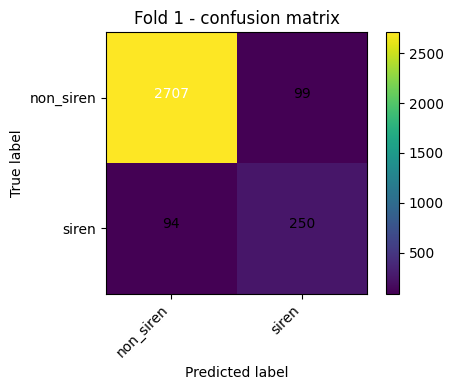


FOLD 2 COMO TEST
X_train: (28138, 64, 50, 1)
X_test: (3144, 64, 50, 1)
Train distribution: {'non_siren': 24871, 'siren': 3267}
Test distribution: {'non_siren': 2780, 'siren': 364}
Class weight: {0: 0.5656789031402034, 1: 4.306397306397306}

Fase 1: entrenamiento de cabeza binaria
Epoch 1/30
879/880 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8108 - auc: 0.8848 - loss: 0.4197 - precision: 0.3846 - recall: 0.8154
Epoch 1: val_loss improved from None to 0.37447, saving model to /content/miniresnet_siren_training/results/models/miniresnet_siren_fold2.keras

Epoch 1: finished saving model to /content/miniresnet_siren_training/results/models/miniresnet_siren_fold2.keras
880/880 ━━━━━━━━━━━━━━━━━━━━ 30s 30ms/step - accuracy: 0.8583 - auc: 0.9288 - loss: 0.3425 - precision: 0.4429 - recall: 0.8537 - val_accuracy: 0.8403 - val_auc: 0.8638 - val_loss: 0.3745 - val_precision: 0.3948 - val_recall: 0.7115 - learning_rate: 1.0000e-04
Epoch 2/30
880/880 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accura

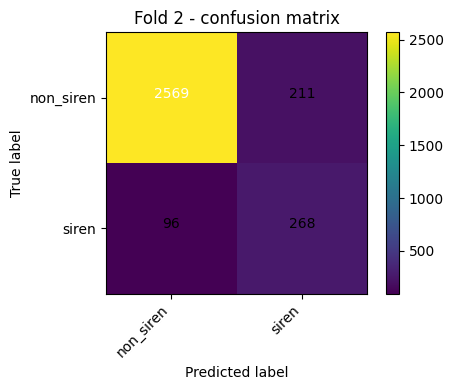


FOLD 3 COMO TEST
X_train: (27905, 64, 50, 1)
X_test: (3377, 64, 50, 1)
Train distribution: {'non_siren': 24747, 'siren': 3158}
Test distribution: {'non_siren': 2904, 'siren': 473}
Class weight: {0: 0.5638057138238979, 1: 4.418144395186827}

Fase 1: entrenamiento de cabeza binaria
Epoch 1/30
870/873 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7191 - auc: 0.8354 - loss: 0.5326 - precision: 0.3156 - recall: 0.7974
Epoch 1: val_loss improved from None to 0.31172, saving model to /content/miniresnet_siren_training/results/models/miniresnet_siren_fold3.keras

Epoch 1: finished saving model to /content/miniresnet_siren_training/results/models/miniresnet_siren_fold3.keras
873/873 ━━━━━━━━━━━━━━━━━━━━ 25s 27ms/step - accuracy: 0.8242 - auc: 0.9093 - loss: 0.3871 - precision: 0.3752 - recall: 0.8322 - val_accuracy: 0.8810 - val_auc: 0.9156 - val_loss: 0.3117 - val_precision: 0.5568 - val_recall: 0.7357 - learning_rate: 1.0000e-04
Epoch 2/30
872/873 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accura

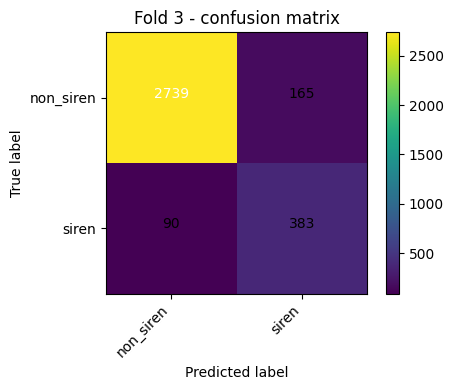


FOLD 4 COMO TEST
X_train: (27784, 64, 50, 1)
X_test: (3498, 64, 50, 1)
Train distribution: {'non_siren': 24794, 'siren': 2990}
Test distribution: {'non_siren': 2857, 'siren': 641}
Class weight: {0: 0.5602968460111317, 1: 4.6461538461538465}

Fase 1: entrenamiento de cabeza binaria
Epoch 1/30
869/869 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7375 - auc: 0.8537 - loss: 0.5100 - precision: 0.3181 - recall: 0.8229
Epoch 1: val_loss improved from None to 0.37323, saving model to /content/miniresnet_siren_training/results/models/miniresnet_siren_fold4.keras

Epoch 1: finished saving model to /content/miniresnet_siren_training/results/models/miniresnet_siren_fold4.keras
869/869 ━━━━━━━━━━━━━━━━━━━━ 28s 28ms/step - accuracy: 0.8305 - auc: 0.9094 - loss: 0.3864 - precision: 0.3724 - recall: 0.8381 - val_accuracy: 0.8505 - val_auc: 0.8959 - val_loss: 0.3732 - val_precision: 0.5669 - val_recall: 0.7800 - learning_rate: 1.0000e-04
Epoch 2/30
869/869 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accur

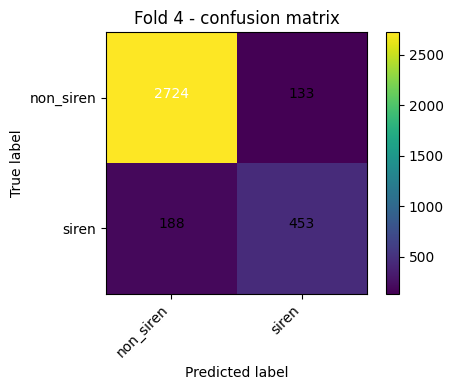


FOLD 5 COMO TEST
X_train: (27982, 64, 50, 1)
X_test: (3300, 64, 50, 1)
Train distribution: {'non_siren': 24622, 'siren': 3360}
Test distribution: {'non_siren': 3029, 'siren': 271}
Class weight: {0: 0.5682316627406384, 1: 4.163988095238095}

Fase 1: entrenamiento de cabeza binaria
Epoch 1/30
873/875 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7305 - auc: 0.7956 - loss: 0.5885 - precision: 0.3038 - recall: 0.7305
Epoch 1: val_loss improved from None to 0.28983, saving model to /content/miniresnet_siren_training/results/models/miniresnet_siren_fold5.keras

Epoch 1: finished saving model to /content/miniresnet_siren_training/results/models/miniresnet_siren_fold5.keras
875/875 ━━━━━━━━━━━━━━━━━━━━ 28s 29ms/step - accuracy: 0.8189 - auc: 0.8945 - loss: 0.4173 - precision: 0.3811 - recall: 0.8140 - val_accuracy: 0.8812 - val_auc: 0.9452 - val_loss: 0.2898 - val_precision: 0.3976 - val_recall: 0.8672 - learning_rate: 1.0000e-04
Epoch 2/30
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accura

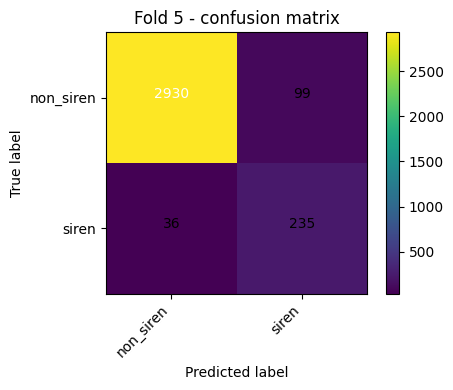


FOLD 6 COMO TEST
X_train: (28332, 64, 50, 1)
X_test: (2950, 64, 50, 1)
Train distribution: {'non_siren': 24994, 'siren': 3338}
Test distribution: {'non_siren': 2657, 'siren': 293}
Class weight: {0: 0.5667760262462991, 1: 4.243858597962852}

Fase 1: entrenamiento de cabeza binaria
Epoch 1/30
885/886 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7668 - auc: 0.8532 - loss: 0.4918 - precision: 0.3504 - recall: 0.7975
Epoch 1: val_loss improved from None to 0.32655, saving model to /content/miniresnet_siren_training/results/models/miniresnet_siren_fold6.keras

Epoch 1: finished saving model to /content/miniresnet_siren_training/results/models/miniresnet_siren_fold6.keras
886/886 ━━━━━━━━━━━━━━━━━━━━ 28s 30ms/step - accuracy: 0.8368 - auc: 0.9113 - loss: 0.3826 - precision: 0.4056 - recall: 0.8274 - val_accuracy: 0.8664 - val_auc: 0.9102 - val_loss: 0.3266 - val_precision: 0.4073 - val_recall: 0.7577 - learning_rate: 1.0000e-04
Epoch 2/30
885/886 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accura

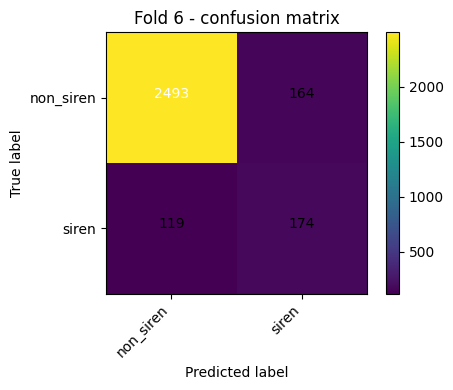


FOLD 7 COMO TEST
X_train: (28236, 64, 50, 1)
X_test: (3046, 64, 50, 1)
Train distribution: {'non_siren': 24899, 'siren': 3337}
Test distribution: {'non_siren': 2752, 'siren': 294}
Class weight: {0: 0.5670107233222218, 1: 4.230746179202876}

Fase 1: entrenamiento de cabeza binaria
Epoch 1/30
882/883 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7681 - auc: 0.8325 - loss: 0.4958 - precision: 0.3314 - recall: 0.7523
Epoch 1: val_loss improved from None to 0.32299, saving model to /content/miniresnet_siren_training/results/models/miniresnet_siren_fold7.keras

Epoch 1: finished saving model to /content/miniresnet_siren_training/results/models/miniresnet_siren_fold7.keras
883/883 ━━━━━━━━━━━━━━━━━━━━ 29s 30ms/step - accuracy: 0.8395 - auc: 0.9124 - loss: 0.3781 - precision: 0.4112 - recall: 0.8289 - val_accuracy: 0.8684 - val_auc: 0.8657 - val_loss: 0.3230 - val_precision: 0.3969 - val_recall: 0.7007 - learning_rate: 1.0000e-04
Epoch 2/30
881/883 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accura

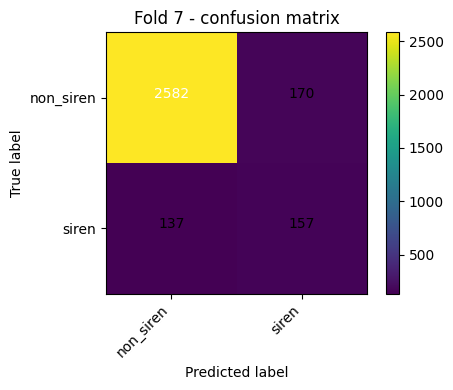


FOLD 8 COMO TEST
X_train: (28419, 64, 50, 1)
X_test: (2863, 64, 50, 1)
Train distribution: {'non_siren': 25105, 'siren': 3314}
Test distribution: {'non_siren': 2546, 'siren': 317}
Class weight: {0: 0.5660027882891854, 1: 4.287718768859384}

Fase 1: entrenamiento de cabeza binaria
Epoch 1/30
888/889 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7730 - auc: 0.8706 - loss: 0.4752 - precision: 0.3543 - recall: 0.8237
Epoch 1: val_loss improved from None to 0.29790, saving model to /content/miniresnet_siren_training/results/models/miniresnet_siren_fold8.keras

Epoch 1: finished saving model to /content/miniresnet_siren_training/results/models/miniresnet_siren_fold8.keras
889/889 ━━━━━━━━━━━━━━━━━━━━ 30s 30ms/step - accuracy: 0.8368 - auc: 0.9110 - loss: 0.3840 - precision: 0.4034 - recall: 0.8340 - val_accuracy: 0.8998 - val_auc: 0.9614 - val_loss: 0.2979 - val_precision: 0.5279 - val_recall: 0.8959 - learning_rate: 1.0000e-04
Epoch 2/30
889/889 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accura

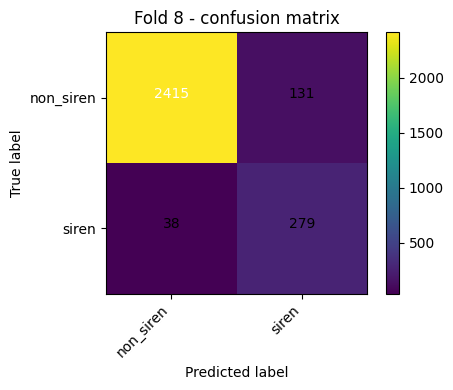


FOLD 9 COMO TEST
X_train: (28336, 64, 50, 1)
X_test: (2946, 64, 50, 1)
Train distribution: {'non_siren': 25024, 'siren': 3312}
Test distribution: {'non_siren': 2627, 'siren': 319}
Class weight: {0: 0.5661764705882353, 1: 4.277777777777778}

Fase 1: entrenamiento de cabeza binaria
Epoch 1/30
885/886 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7639 - auc: 0.8583 - loss: 0.4811 - precision: 0.3437 - recall: 0.7993
Epoch 1: val_loss improved from None to 0.25411, saving model to /content/miniresnet_siren_training/results/models/miniresnet_siren_fold9.keras

Epoch 1: finished saving model to /content/miniresnet_siren_training/results/models/miniresnet_siren_fold9.keras
886/886 ━━━━━━━━━━━━━━━━━━━━ 30s 31ms/step - accuracy: 0.8393 - auc: 0.9150 - loss: 0.3738 - precision: 0.4081 - recall: 0.8324 - val_accuracy: 0.9036 - val_auc: 0.9371 - val_loss: 0.2541 - val_precision: 0.5362 - val_recall: 0.8119 - learning_rate: 1.0000e-04
Epoch 2/30
886/886 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accura

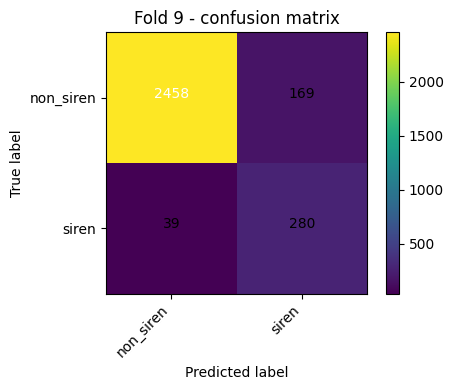


FOLD 10 COMO TEST
X_train: (28274, 64, 50, 1)
X_test: (3008, 64, 50, 1)
Train distribution: {'non_siren': 24958, 'siren': 3316}
Test distribution: {'non_siren': 2693, 'siren': 315}
Class weight: {0: 0.5664316050965622, 1: 4.263268998793728}

Fase 1: entrenamiento de cabeza binaria
Epoch 1/30
883/884 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7600 - auc: 0.8501 - loss: 0.5191 - precision: 0.3498 - recall: 0.7972
Epoch 1: val_loss improved from None to 0.34438, saving model to /content/miniresnet_siren_training/results/models/miniresnet_siren_fold10.keras

Epoch 1: finished saving model to /content/miniresnet_siren_training/results/models/miniresnet_siren_fold10.keras
884/884 ━━━━━━━━━━━━━━━━━━━━ 30s 31ms/step - accuracy: 0.8393 - auc: 0.9131 - loss: 0.3813 - precision: 0.4094 - recall: 0.8366 - val_accuracy: 0.8674 - val_auc: 0.7903 - val_loss: 0.3444 - val_precision: 0.3976 - val_recall: 0.5175 - learning_rate: 1.0000e-04
Epoch 2/30
883/884 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - acc

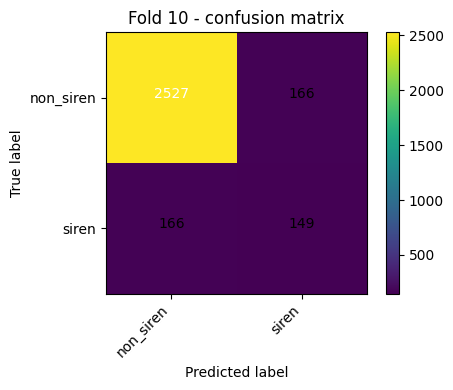


RESULTADOS K-FOLD AGREGADOS


,test_fold,n_train,n_test,accuracy,precision,recall,f1,auc,threshold,model_path
0,1,28132,3150,0.938730,0.716332,0.726744,0.721501,0.917477,0.5,/content/miniresnet_siren_training/results/mod...
1,2,28138,3144,0.902354,0.559499,0.736264,0.635824,0.903093,0.5,/content/miniresnet_siren_training/results/mod...
2,3,27905,3377,0.924489,0.698905,0.809725,0.750245,0.944027,0.5,/content/miniresnet_siren_training/results/mod...
3,4,27784,3498,0.908233,0.773038,0.706708,0.738386,0.930178,0.5,/content/miniresnet_siren_training/results/mod...
4,5,27982,3300,0.959091,0.703593,0.867159,0.776860,0.966250,0.5,/content/miniresnet_siren_training/results/mod...
5,6,28332,2950,0.904068,0.514793,0.593857,0.551506,0.919657,0.5,/content/miniresnet_siren_training/results/mod...
6,7,28236,3046,0.899212,0.480122,0.534014,0.505636,0.884257,0.5,/content/miniresnet_siren_training/results/mod...
7,8,28419,2863,0.940971,0.680488,0.880126,0.767538,0.969683,0.5,/content/miniresnet_siren_training/results/mod...
8,9,28336,2946,0.929396,0.623608,0.877743,0.729167,0.971039,0.5,/content/miniresnet_siren_training/results/mod...
9,10,28274,3008,0.889628,0.473016,0.473016,0.473016,0.801353,0.5,/content/miniresnet_siren_training/results/mod...


,accuracy,precision,recall,f1,auc
mean,0.919617,0.622339,0.720536,0.664968,0.920702
std,0.022321,0.108233,0.146142,0.114976,0.051137


In [ ]:
fold_results = []
fold_histories = []

if RUN_KFOLD:
    for test_fold in range(1, 11):
        print("\n" + "=" * 70)
        print(f"FOLD {test_fold} COMO TEST")
        print("=" * 70)

        train_mask = folds_all != test_fold
        test_mask = folds_all == test_fold

        X_train = X_all[train_mask]
        y_train = y_all[train_mask]

        X_test = X_all[test_mask]
        y_test = y_all[test_mask]

        print("X_train:", X_train.shape)
        print("X_test:", X_test.shape)

        print("Train distribution:", pd.Series(y_train.astype(int)).map(INDEX_TO_CLASS).value_counts().to_dict())
        print("Test distribution:", pd.Series(y_test.astype(int)).map(INDEX_TO_CLASS).value_counts().to_dict())

        train_ds = make_tf_dataset(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True)
        test_ds = make_tf_dataset(X_test, y_test, batch_size=BATCH_SIZE, shuffle=False)

        class_weight = compute_binary_class_weight(y_train)
        print("Class weight:", class_weight)

        model = build_siren_model(
            model_path=MODEL_PATH,
            freeze_base=True,
            learning_rate=LEARNING_RATE_HEAD
        )

        fold_model_path = MODELS_DIR / f"miniresnet_siren_fold{test_fold}.keras"
        fold_history_path = RESULTS_DIR / f"history_fold{test_fold}.csv"

        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=PATIENCE,
                restore_best_weights=True,
                verbose=1
            ),
            tf.keras.callbacks.ModelCheckpoint(
                filepath=str(fold_model_path),
                monitor="val_loss",
                save_best_only=True,
                verbose=1
            ),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss",
                factor=0.5,
                patience=3,
                min_lr=1e-7,
                verbose=1
            )
        ]

        print("\nFase 1: entrenamiento de cabeza binaria")
        history_head = model.fit(
            train_ds,
            validation_data=test_ds,
            epochs=EPOCHS_HEAD,
            callbacks=callbacks,
            class_weight=class_weight,
            verbose=1
        )

        # Fine-tuning de las últimas capas.
        print("\nFase 2: fine-tuning de últimas capas")
        model = unfreeze_last_layers(
            model,
            n_layers=20,
            learning_rate=LEARNING_RATE_FINE
        )

        history_fine = model.fit(
            train_ds,
            validation_data=test_ds,
            epochs=EPOCHS_FINE,
            callbacks=callbacks,
            class_weight=class_weight,
            verbose=1
        )

        # Cargar mejor modelo guardado.
        best_model = tf.keras.models.load_model(fold_model_path, compile=False)

        y_prob = predict_probabilities(best_model, X_test)
        eval_result = evaluate_binary_predictions(
            y_test,
            y_prob,
            threshold=DEFAULT_THRESHOLD
        )

        print("\nResultados fold", test_fold)
        print("Accuracy :", eval_result["accuracy"])
        print("Precision:", eval_result["precision"])
        print("Recall   :", eval_result["recall"])
        print("F1       :", eval_result["f1"])
        print("AUC      :", eval_result["auc"])
        print("\nClassification report:")
        print(eval_result["classification_report"])

        plot_confusion_matrix(
            eval_result["confusion_matrix"],
            title=f"Fold {test_fold} - confusion matrix"
        )

        # Guardar predicciones del fold.
        fold_pred_df = pd.DataFrame({
            "fold": test_fold,
            "true_label_index": y_test.astype(int),
            "true_label_name": [INDEX_TO_CLASS[int(v)] for v in y_test],
            "prob_siren": y_prob,
            "pred_label_index": (y_prob >= DEFAULT_THRESHOLD).astype(int),
            "pred_label_name": [INDEX_TO_CLASS[int(v)] for v in (y_prob >= DEFAULT_THRESHOLD).astype(int)],
        })

        fold_pred_df.to_csv(
            RESULTS_DIR / f"predictions_fold{test_fold}.csv",
            index=False
        )

        fold_results.append({
            "test_fold": test_fold,
            "n_train": int(len(y_train)),
            "n_test": int(len(y_test)),
            "accuracy": eval_result["accuracy"],
            "precision": eval_result["precision"],
            "recall": eval_result["recall"],
            "f1": eval_result["f1"],
            "auc": eval_result["auc"],
            "threshold": DEFAULT_THRESHOLD,
            "model_path": str(fold_model_path),
        })

        # Combinar historial de las dos fases.
        hist_head_df = pd.DataFrame(history_head.history)
        hist_head_df["phase"] = "head"

        hist_fine_df = pd.DataFrame(history_fine.history)
        hist_fine_df["phase"] = "fine_tuning"

        hist_df = pd.concat([hist_head_df, hist_fine_df], ignore_index=True)
        hist_df.to_csv(fold_history_path, index=False)

        fold_histories.append(hist_df)

    results_df = pd.DataFrame(fold_results)
    results_df.to_csv(RESULTS_DIR / "kfold_results.csv", index=False)

    print("\n" + "=" * 70)
    print("RESULTADOS K-FOLD AGREGADOS")
    print("=" * 70)

    display(results_df)

    summary_stats = results_df[[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "auc"
    ]].agg(["mean", "std"])

    display(summary_stats)

    summary_stats.to_csv(RESULTS_DIR / "kfold_summary_stats.csv")

else:
    print("RUN_KFOLD=False, se omite entrenamiento k-fold.")


 14. ENTRENAMIENTO FINAL CON TODOS LOS DATOS

In [ ]:
if RUN_FINAL_TRAINING:
    print("\n" + "=" * 70)
    print("ENTRENAMIENTO FINAL CON TODOS LOS FOLDS")
    print("=" * 70)

    X_final = X_all
    y_final = y_all

    final_ds = make_tf_dataset(X_final, y_final, batch_size=BATCH_SIZE, shuffle=True)

    final_class_weight = compute_binary_class_weight(y_final)
    print("Final class weight:", final_class_weight)

    final_model = build_siren_model(
        model_path=MODEL_PATH,
        freeze_base=True,
        learning_rate=LEARNING_RATE_HEAD
    )

    final_model_path = MODELS_DIR / "miniresnetv1_s1_64x50_siren_final.keras"

    # Al usar todos los datos, no hay validación externa.
    # Para no depender de val_loss, guardamos el modelo al final.
    print("\nFase 1 final: cabeza binaria")
    final_history_head = final_model.fit(
        final_ds,
        epochs=EPOCHS_HEAD,
        class_weight=final_class_weight,
        verbose=1
    )

    print("\nFase 2 final: fine-tuning")
    final_model = unfreeze_last_layers(
        final_model,
        n_layers=20,
        learning_rate=LEARNING_RATE_FINE
    )

    final_history_fine = final_model.fit(
        final_ds,
        epochs=EPOCHS_FINE,
        class_weight=final_class_weight,
        verbose=1
    )

    final_model.save(final_model_path)

    print("Modelo final guardado en:", final_model_path)

    final_hist_head_df = pd.DataFrame(final_history_head.history)
    final_hist_head_df["phase"] = "head"

    final_hist_fine_df = pd.DataFrame(final_history_fine.history)
    final_hist_fine_df["phase"] = "fine_tuning"

    final_hist_df = pd.concat([final_hist_head_df, final_hist_fine_df], ignore_index=True)
    final_hist_df.to_csv(RESULTS_DIR / "history_final_model.csv", index=False)

else:
    print("RUN_FINAL_TRAINING=False, se omite entrenamiento final.")



ENTRENAMIENTO FINAL CON TODOS LOS FOLDS
Final class weight: {0: 0.5656576615673936, 1: 4.307628752409804}

Fase 1 final: cabeza binaria
Epoch 1/30
978/978 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - accuracy: 0.8415 - auc: 0.9168 - loss: 0.3720 - precision: 0.4106 - recall: 0.8403
Epoch 2/30
978/978 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - accuracy: 0.9098 - auc: 0.9664 - loss: 0.2354 - precision: 0.5700 - recall: 0.9083
Epoch 3/30
978/978 ━━━━━━━━━━━━━━━━━━━━ 24s 24ms/step - accuracy: 0.9286 - auc: 0.9780 - loss: 0.1910 - precision: 0.6309 - recall: 0.9276
Epoch 4/30
978/978 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.9403 - auc: 0.9841 - loss: 0.1637 - precision: 0.6746 - recall: 0.9389
Epoch 5/30
978/978 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accuracy: 0.9473 - auc: 0.9877 - loss: 0.1452 - precision: 0.7018 - recall: 0.9488
Epoch 6/30
978/978 ━━━━━━━━━━━━━━━━━━━━ 41s 25ms/step - accuracy: 0.9536 - auc: 0.9905 - loss: 0.1297 - precision: 0.7275 - recall: 0.9590
Epoch 7/30
978/978 ━━━━━━━━━━

15. EVALUACIÓN RÁPIDA DEL MODELO FINAL


Evaluación sobre todos los datos usados en entrenamiento final.
OJO: esto no sustituye al k-fold. Solo comprueba que el modelo final aprende.
Accuracy : 0.9468704047055815
Precision: 0.6964677709040111
Recall   : 0.9611677223905261
F1       : 0.8076834066188382
AUC      : 0.989266562577835

Classification report:
              precision    recall  f1-score   support

   non_siren       0.99      0.94      0.97     27651
       siren       0.70      0.96      0.81      3631

    accuracy                           0.95     31282
   macro avg       0.85      0.95      0.89     31282
weighted avg       0.96      0.95      0.95     31282



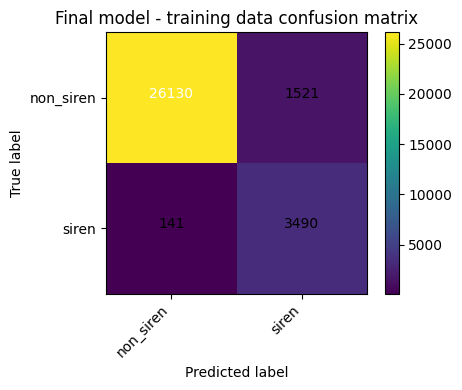

In [ ]:
if RUN_FINAL_TRAINING:
    final_model_loaded = tf.keras.models.load_model(final_model_path, compile=False)

    y_prob_all = predict_probabilities(final_model_loaded, X_all)
    final_train_eval = evaluate_binary_predictions(
        y_all,
        y_prob_all,
        threshold=DEFAULT_THRESHOLD
    )

    print("\nEvaluación sobre todos los datos usados en entrenamiento final.")
    print("OJO: esto no sustituye al k-fold. Solo comprueba que el modelo final aprende.")
    print("Accuracy :", final_train_eval["accuracy"])
    print("Precision:", final_train_eval["precision"])
    print("Recall   :", final_train_eval["recall"])
    print("F1       :", final_train_eval["f1"])
    print("AUC      :", final_train_eval["auc"])

    print("\nClassification report:")
    print(final_train_eval["classification_report"])

    plot_confusion_matrix(
        final_train_eval["confusion_matrix"],
        title="Final model - training data confusion matrix"
    )


16. Exploración diagnóstica del umbral sobre los datos de entrenamiento

Este barrido se conserva como análisis diagnóstico del modelo final.
Al realizarse sobre los mismos datos utilizados durante el entrenamiento final,
no se emplea para justificar el umbral operativo del sistema.

El análisis del umbral de despliegue se realiza posteriormente utilizando
predicciones out-of-fold del modelo cuantizado int8.

In [ ]:
def threshold_sweep(y_true, y_prob, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.1, 0.9, 17)

    records = []

    for th in thresholds:
        result = evaluate_binary_predictions(y_true, y_prob, threshold=float(th))

        records.append({
            "threshold": float(th),
            "accuracy": result["accuracy"],
            "precision": result["precision"],
            "recall": result["recall"],
            "f1": result["f1"],
            "auc": result["auc"],
        })

    return pd.DataFrame(records)


if RUN_FINAL_TRAINING:
    sweep_df = threshold_sweep(y_all, y_prob_all)
    display(sweep_df)
    sweep_df.to_csv(RESULTS_DIR / "threshold_sweep_final_training_data.csv", index=False)

    plt.figure(figsize=(8, 4))
    plt.plot(sweep_df["threshold"], sweep_df["precision"], label="precision")
    plt.plot(sweep_df["threshold"], sweep_df["recall"], label="recall")
    plt.plot(sweep_df["threshold"], sweep_df["f1"], label="f1")
    plt.xlabel("Threshold")
    plt.ylabel("Metric")
    plt.title("Threshold sweep - final model")
    plt.legend()
    plt.tight_layout()
    plt.show()

17. PREDICCIÓN DE UN ARCHIVO INDIVIDUAL


Ejemplo SIREN:
File: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/UrbanSound8K/audio/fold7/102853-8-0-0.wav
N windows: 4
Prob siren: 0.9528163969516754
Threshold: 0.5
Prediction: siren


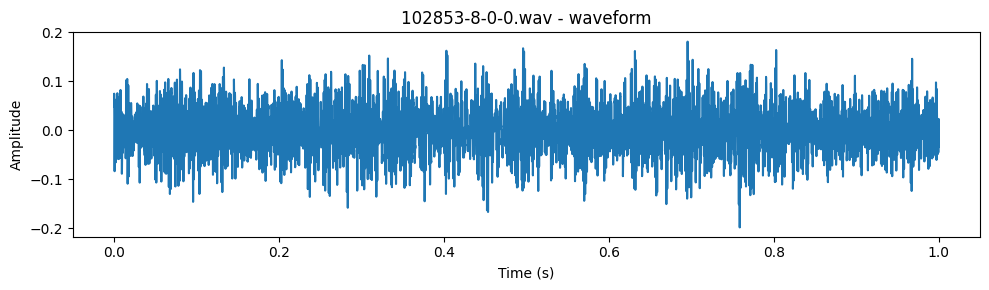

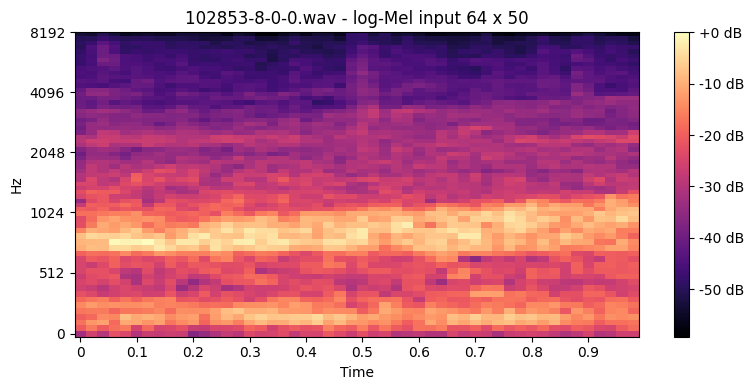


Ejemplo NON_SIREN:
File: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/UrbanSound8K/audio/fold5/100032-3-0-0.wav
N windows: 1
Prob siren: 0.003860322292894125
Threshold: 0.5
Prediction: non_siren


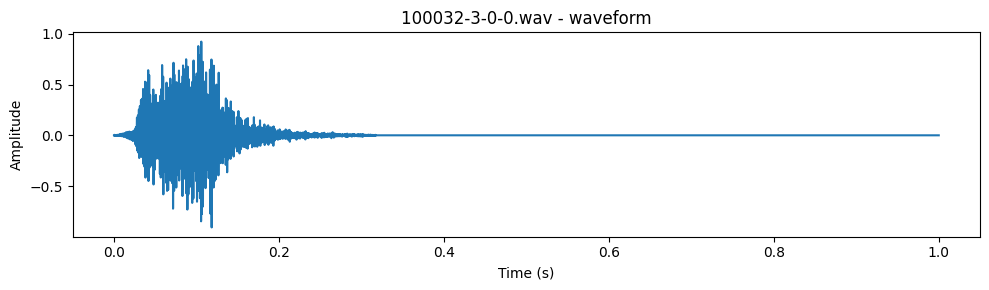

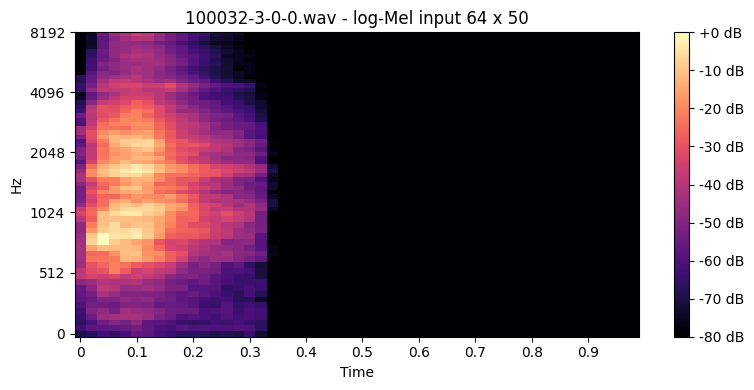

In [ ]:
def predict_single_file_binary(
    model,
    filepath,
    strategy=EVAL_STRATEGY,
    threshold=DEFAULT_THRESHOLD,
    plot=True
):
    y_audio, _ = load_audio_mono(filepath, SAMPLE_RATE)

    if strategy == "first_second":
        windows = [fix_audio_length(y_audio, N_SAMPLES)]
    elif strategy == "full_clip_mean":
        windows = split_audio_into_windows(
            y_audio,
            n_samples=N_SAMPLES,
            hop_samples=N_SAMPLES
        )
    else:
        raise ValueError(f"Estrategia no soportada: {strategy}")

    probs = []
    first_info = None

    for i, w in enumerate(windows):
        tensor, info = preprocess_audio_array_to_logmel(
            w,
            return_intermediate=True
        )

        prob = model.predict(tensor, verbose=0).reshape(-1)[0]
        probs.append(float(prob))

        if i == 0:
            first_info = info

    prob_siren = float(np.mean(probs))
    pred_index = int(prob_siren >= threshold)
    pred_label = INDEX_TO_CLASS[pred_index]

    print("File:", filepath)
    print("N windows:", len(windows))
    print("Prob siren:", prob_siren)
    print("Threshold:", threshold)
    print("Prediction:", pred_label)

    if plot and first_info is not None:
        plot_waveform_and_logmel(
            first_info["audio"],
            first_info["logmel_fixed"],
            title_prefix=Path(filepath).name
        )

    return {
        "filepath": str(filepath),
        "prob_siren": prob_siren,
        "predicted_index": pred_index,
        "predicted_label": pred_label,
        "n_windows": len(windows),
        "window_probs": probs,
    }


if RUN_FINAL_TRAINING:
    # Buscar un ejemplo de sirena.
    siren_example = metadata[metadata["label_index"] == 1].iloc[0]
    non_siren_example = metadata[metadata["label_index"] == 0].iloc[0]

    print("\nEjemplo SIREN:")
    result_siren = predict_single_file_binary(
        final_model_loaded,
        siren_example["filepath"],
        threshold=DEFAULT_THRESHOLD,
        plot=True
    )

    print("\nEjemplo NON_SIREN:")
    result_non_siren = predict_single_file_binary(
        final_model_loaded,
        non_siren_example["filepath"],
        threshold=DEFAULT_THRESHOLD,
        plot=True
    )

18. EXPORTAR UNA MUESTRA A .H PARA STM32

In [ ]:
def export_logmel_to_c_header(logmel_tensor, output_path, array_name="test_input"):
    """Exporta tensor (1,64,50,1) como array C float de 3200 valores."""
    output_path = Path(output_path)

    arr = np.asarray(logmel_tensor, dtype=np.float32)

    if arr.shape != (1, N_MELS, TARGET_FRAMES, 1):
        raise ValueError(
            f"Forma incorrecta: {arr.shape}, esperada {(1, N_MELS, TARGET_FRAMES, 1)}"
        )

    flat = arr.reshape(-1).astype(np.float32)

    if len(flat) != N_MELS * TARGET_FRAMES:
        raise ValueError(
            f"Tamaño incorrecto: {len(flat)}, esperado {N_MELS * TARGET_FRAMES}"
        )

    guard = output_path.name.replace(".", "_").replace("-", "_").upper()

    lines = []
    lines.append(f"#ifndef {guard}")
    lines.append(f"#define {guard}")
    lines.append("")
    lines.append(f"#define {array_name.upper()}_SIZE {len(flat)}")
    lines.append("")
    lines.append(f"const float {array_name}[{array_name.upper()}_SIZE] = {{")

    for i in range(0, len(flat), 8):
        chunk = flat[i:i + 8]
        values = ", ".join([f"{float(v):.8e}f" for v in chunk])
        lines.append("    " + values + ",")

    lines.append("};")
    lines.append("")
    lines.append(f"#endif /* {guard} */")
    lines.append("")

    output_path.write_text("\n".join(lines))

    return output_path, flat


# Selección de la clase de la muestra utilizada para la exportación.
EXPORT_CLASS = "siren"

if EXPORT_CLASS == "siren":
    export_row = metadata[metadata["label_index"] == 1].iloc[0]
else:
    export_row = metadata[metadata["label_index"] == 0].iloc[0]

export_tensor, export_info = preprocess_audio_to_logmel(
    export_row["filepath"],
    return_intermediate=True
)

header_path = EXPORT_DIR / "test_input.h"
npy_path = EXPORT_DIR / "test_input.npy"

header_path, flat = export_logmel_to_c_header(
    export_tensor,
    header_path,
    array_name="test_input"
)

np.save(npy_path, export_tensor)

print("Exported header:", header_path)
print("Exported npy:", npy_path)
print("Header values:", len(flat))
print("Tensor shape:", export_tensor.shape)
print("Tensor dtype:", export_tensor.dtype)
print("Real frames before padding:", export_info["real_frames"])

if RUN_FINAL_TRAINING:
    export_prob = final_model_loaded.predict(export_tensor, verbose=0).reshape(-1)[0]
    export_pred = int(export_prob >= DEFAULT_THRESHOLD)

    print("\nColab prediction for exported sample:")
    print("File:", export_row["slice_file_name"])
    print("Original class:", export_row["class"])
    print("Binary true label:", export_row["label_name"])
    print("Prob siren:", float(export_prob))
    print("Predicted:", INDEX_TO_CLASS[export_pred])

Exported header: /content/miniresnet_siren_training/results/exported_inputs/test_input.h
Exported npy: /content/miniresnet_siren_training/results/exported_inputs/test_input.npy
Header values: 3200
Tensor shape: (1, 64, 50, 1)
Tensor dtype: float32
Real frames before padding: 51

Colab prediction for exported sample:
File: 102853-8-0-0.wav
Original class: siren
Binary true label: siren
Prob siren: 0.995785117149353
Predicted: siren


18.2. GUARDADO PERSISTENTE COMPLETO EN GOOGLE DRIVE

In [ ]:
# ============================================================
# 18.2. GUARDADO PERSISTENTE COMPLETO EN GOOGLE DRIVE
# ============================================================
# Esta sección copia/guarda todo lo necesario para poder cerrar Colab
# y retomar después desde la comparación Colab vs STM32/X-CUBE-AI.
#
# Guarda:
# - Modelo final .keras, si existe
# - Modelos por fold, si existen
# - Configuración del entrenamiento
# - Resultados k-fold
# - Caché de features log-Mel
# - Entrada exportada .h y .npy
# - Predicción Colab de la muestra exportada
# - Metadata de la muestra exportada

import json
import shutil
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf

# Carpeta persistente dentro del proyecto en Drive
PERSISTENT_DIR = PROJECT_ROOT / "siren_training_persistent_state"
PERSISTENT_MODELS_DIR = PERSISTENT_DIR / "models"
PERSISTENT_RESULTS_DIR = PERSISTENT_DIR / "results"
PERSISTENT_CACHE_DIR = PERSISTENT_DIR / "feature_cache"
PERSISTENT_EXPORT_DIR = PERSISTENT_DIR / "exported_inputs"

for d in [
    PERSISTENT_DIR,
    PERSISTENT_MODELS_DIR,
    PERSISTENT_RESULTS_DIR,
    PERSISTENT_CACHE_DIR,
    PERSISTENT_EXPORT_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

print("Carpeta persistente:", PERSISTENT_DIR)


# ------------------------------------------------------------
# Funciones auxiliares
# ------------------------------------------------------------

def copy_file_if_exists(src, dst):
    src = Path(src)
    dst = Path(dst)

    if src.exists():
        dst.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(src, dst)
        print(f"Copiado: {src} -> {dst}")
        return True
    else:
        print(f"No existe, se omite: {src}")
        return False


def copy_folder_contents_if_exists(src_dir, dst_dir, patterns=None):
    src_dir = Path(src_dir)
    dst_dir = Path(dst_dir)
    dst_dir.mkdir(parents=True, exist_ok=True)

    if not src_dir.exists():
        print(f"No existe carpeta, se omite: {src_dir}")
        return

    if patterns is None:
        patterns = ["*"]

    copied = 0

    for pattern in patterns:
        for src in src_dir.glob(pattern):
            if src.is_file():
                dst = dst_dir / src.name
                shutil.copy2(src, dst)
                copied += 1
                print(f"Copiado: {src} -> {dst}")

    print(f"Archivos copiados desde {src_dir}: {copied}")


# ------------------------------------------------------------
# 1. Guardar/copiar modelos
# ------------------------------------------------------------

# Copia todos los modelos guardados en MODELS_DIR:
# - miniresnet_siren_fold1.keras
# - ...
# - miniresnetv1_s1_64x50_siren_final.keras

copy_folder_contents_if_exists(
    src_dir=MODELS_DIR,
    dst_dir=PERSISTENT_MODELS_DIR,
    patterns=["*.keras", "*.h5"]
)


# Si existe final_model en memoria, guardarlo explícitamente también
# con un nombre estable.
try:
    if "final_model" in globals():
        final_model_persistent_path = PERSISTENT_MODELS_DIR / "miniresnetv1_s1_64x50_siren_final.keras"
        final_model.save(final_model_persistent_path)
        print("Modelo final guardado explícitamente en:", final_model_persistent_path)
except Exception as e:
    print("No se pudo guardar final_model desde memoria:", e)


# Si existe final_model_loaded en memoria, también se puede guardar.
try:
    if "final_model_loaded" in globals():
        final_model_loaded_persistent_path = PERSISTENT_MODELS_DIR / "miniresnetv1_s1_64x50_siren_final_loaded_copy.keras"
        final_model_loaded.save(final_model_loaded_persistent_path)
        print("Copia de final_model_loaded guardada en:", final_model_loaded_persistent_path)
except Exception as e:
    print("No se pudo guardar final_model_loaded desde memoria:", e)


# ------------------------------------------------------------
# 2. Guardar caché de features
# ------------------------------------------------------------

# Copia archivos ya existentes de CACHE_DIR a Drive persistente.
copy_folder_contents_if_exists(
    src_dir=CACHE_DIR,
    dst_dir=PERSISTENT_CACHE_DIR,
    patterns=["*.npy", "*.csv"]
)

# Además, si las variables están en memoria, las guardamos explícitamente.
try:
    if "X_all" in globals():
        np.save(PERSISTENT_CACHE_DIR / "X_logmel_64x50.npy", X_all)
        print("X_all guardado en caché persistente.")

    if "y_all" in globals():
        np.save(PERSISTENT_CACHE_DIR / "y_binary.npy", y_all)
        print("y_all guardado en caché persistente.")

    if "folds_all" in globals():
        np.save(PERSISTENT_CACHE_DIR / "folds.npy", folds_all)
        print("folds_all guardado en caché persistente.")

    if "windows_df" in globals():
        windows_df.to_csv(PERSISTENT_CACHE_DIR / "windows_metadata.csv", index=False)
        print("windows_df guardado en caché persistente.")

except Exception as e:
    print("No se pudo guardar completamente la caché desde memoria:", e)


# ------------------------------------------------------------
# 3. Guardar resultados y métricas
# ------------------------------------------------------------

copy_folder_contents_if_exists(
    src_dir=RESULTS_DIR,
    dst_dir=PERSISTENT_RESULTS_DIR,
    patterns=["*.csv", "*.json", "*.txt"]
)

# Guardar fold_results si existe en memoria.
try:
    if "fold_results" in globals() and len(fold_results) > 0:
        fold_results_df = pd.DataFrame(fold_results)
        fold_results_df.to_csv(PERSISTENT_RESULTS_DIR / "kfold_results_from_memory.csv", index=False)
        print("fold_results guardado desde memoria.")
except Exception as e:
    print("No se pudo guardar fold_results desde memoria:", e)


# ------------------------------------------------------------
# 4. Guardar entrada exportada para STM32
# ------------------------------------------------------------

copy_folder_contents_if_exists(
    src_dir=EXPORT_DIR,
    dst_dir=PERSISTENT_EXPORT_DIR,
    patterns=["*.h", "*.npy", "*.csv", "*.json", "*.txt"]
)

# Guardar export_tensor si existe en memoria.
try:
    if "export_tensor" in globals():
        np.save(PERSISTENT_EXPORT_DIR / "test_input.npy", export_tensor)
        print("export_tensor guardado como test_input.npy.")

    if "flat" in globals():
        np.save(PERSISTENT_EXPORT_DIR / "test_input_flat.npy", flat)
        print("flat input guardado como test_input_flat.npy.")

except Exception as e:
    print("No se pudo guardar export_tensor/flat desde memoria:", e)


# ------------------------------------------------------------
# 5. Guardar metadata de la muestra exportada
# ------------------------------------------------------------

export_metadata = {}

try:
    if "export_row" in globals():
        export_metadata = {
            "slice_file_name": str(export_row.get("slice_file_name", "")),
            "filepath": str(export_row.get("filepath", "")),
            "fold": int(export_row.get("fold", -1)),
            "original_class": str(export_row.get("class", "")),
            "label_index": int(export_row.get("label_index", -1)),
            "label_name": str(export_row.get("label_name", "")),
            "export_class": str(EXPORT_CLASS) if "EXPORT_CLASS" in globals() else None,
        }

    if "export_info" in globals():
        export_metadata["real_frames_before_padding"] = int(export_info.get("real_frames", -1))

    if "export_prob" in globals():
        export_metadata["colab_prob_siren"] = float(export_prob)
        export_metadata["colab_predicted_index"] = int(export_prob >= DEFAULT_THRESHOLD)
        export_metadata["colab_predicted_label"] = INDEX_TO_CLASS[int(export_prob >= DEFAULT_THRESHOLD)]

    export_metadata["threshold"] = float(DEFAULT_THRESHOLD)
    export_metadata["input_shape"] = [1, N_MELS, TARGET_FRAMES, 1]
    export_metadata["n_input_values"] = int(N_MELS * TARGET_FRAMES)

    export_metadata_path = PERSISTENT_EXPORT_DIR / "exported_sample_metadata.json"
    export_metadata_path.write_text(
        json.dumps(export_metadata, indent=2, ensure_ascii=False),
        encoding="utf-8"
    )

    print("Metadata de muestra exportada guardada en:", export_metadata_path)

except Exception as e:
    print("No se pudo guardar metadata de la muestra exportada:", e)


# ------------------------------------------------------------
# 6. Guardar configuración completa de reanudación
# ------------------------------------------------------------

resume_config = {
    "PROJECT_ROOT": str(PROJECT_ROOT),
    "PERSISTENT_DIR": str(PERSISTENT_DIR),
    "PERSISTENT_MODELS_DIR": str(PERSISTENT_MODELS_DIR),
    "PERSISTENT_RESULTS_DIR": str(PERSISTENT_RESULTS_DIR),
    "PERSISTENT_CACHE_DIR": str(PERSISTENT_CACHE_DIR),
    "PERSISTENT_EXPORT_DIR": str(PERSISTENT_EXPORT_DIR),

    "MODEL_PATH": str(MODEL_PATH),
    "URBANSOUND_ROOT": str(URBANSOUND_ROOT),
    "URBANSOUND_CSV_PATH": str(URBANSOUND_CSV_PATH),
    "AUDIO_ROOT": str(AUDIO_ROOT),

    "SAMPLE_RATE": SAMPLE_RATE,
    "AUDIO_DURATION": AUDIO_DURATION,
    "N_SAMPLES": N_SAMPLES,
    "FRAME_SIZE": FRAME_SIZE,
    "HOP_SIZE": HOP_SIZE,
    "N_FFT": N_FFT,
    "N_MELS": N_MELS,
    "TARGET_FRAMES": TARGET_FRAMES,
    "TOP_DB": TOP_DB,
    "FMIN": FMIN,
    "FMAX": FMAX,
    "STFT_CENTER": STFT_CENTER,
    "USE_GLOBAL_DB_REFERENCE": USE_GLOBAL_DB_REFERENCE,
    "GLOBAL_POWER_REFERENCE": GLOBAL_POWER_REFERENCE,

    "CLASS_NAMES": CLASS_NAMES,
    "CLASS_TO_INDEX": CLASS_TO_INDEX,
    "INDEX_TO_CLASS": INDEX_TO_CLASS,

    "TRAIN_STRATEGY": TRAIN_STRATEGY,
    "EVAL_STRATEGY": EVAL_STRATEGY,
    "DEFAULT_THRESHOLD": DEFAULT_THRESHOLD,

    "final_model_expected_path": str(PERSISTENT_MODELS_DIR / "miniresnetv1_s1_64x50_siren_final.keras"),
    "exported_input_header_path": str(PERSISTENT_EXPORT_DIR / "test_input.h"),
    "exported_input_npy_path": str(PERSISTENT_EXPORT_DIR / "test_input.npy"),
    "exported_sample_metadata_path": str(PERSISTENT_EXPORT_DIR / "exported_sample_metadata.json"),
}

resume_config_path = PERSISTENT_DIR / "resume_config.json"
resume_config_path.write_text(
    json.dumps(resume_config, indent=2, ensure_ascii=False),
    encoding="utf-8"
)

print("\nConfiguración de reanudación guardada en:")
print(resume_config_path)


# ------------------------------------------------------------
# 7. Resumen final
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("GUARDADO PERSISTENTE COMPLETADO")
print("=" * 70)

print("Carpeta persistente:")
print(PERSISTENT_DIR)

print("\nModelos persistentes:")
for p in sorted(PERSISTENT_MODELS_DIR.glob("*")):
    print(" -", p.name)

print("\nCaché persistente:")
for p in sorted(PERSISTENT_CACHE_DIR.glob("*")):
    print(" -", p.name)

print("\nExport persistente:")
for p in sorted(PERSISTENT_EXPORT_DIR.glob("*")):
    print(" -", p.name)

print("\nResultados persistentes:")
for p in sorted(PERSISTENT_RESULTS_DIR.glob("*")):
    print(" -", p.name)

Carpeta persistente: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state
Copiado: /content/miniresnet_siren_training/results/models/miniresnetv1_s1_64x50_siren_final.keras -> /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state/models/miniresnetv1_s1_64x50_siren_final.keras
Copiado: /content/miniresnet_siren_training/results/models/miniresnet_siren_fold10.keras -> /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state/models/miniresnet_siren_fold10.keras
Copiado: /content/miniresnet_siren_training/results/models/miniresnet_siren_fold6.keras -> /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state/models/miniresnet_siren_fold6.keras
Copiado: /content/miniresnet_siren_training/results/models/miniresnet_siren_fold1.keras -> /content/drive/MyDrive/Colab Notebooks/TFM/

18.3. CARGA/REANUDACIÓN DESDE ESTADO PERSISTENTE

In [3]:
# ============================================================
# 18.3. CARGA/REANUDACIÓN DESDE ESTADO PERSISTENTE
# ============================================================
# Ejecutar esta sección después de reiniciar Colab para recuperar:
# - Modelo final
# - Tensor exportado
# - Metadata de la muestra exportada
# - Caché de features, si hace falta
# - Configuración
#
# La reanudación permite continuar directamente en la sección 19:
# COMPARACIÓN COLAB VS STM32/X-CUBE-AI

import json
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf

# Google Drive debe estar montado antes de ejecutar esta sección:
# from google.colab import drive
# drive.mount("/content/drive")

# Ruta raíz del proyecto utilizada para recuperar el estado persistente.
PROJECT_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren")

PERSISTENT_DIR = PROJECT_ROOT / "siren_training_persistent_state"
resume_config_path = PERSISTENT_DIR / "resume_config.json"

if not resume_config_path.exists():
    raise FileNotFoundError(
        f"No se encuentra resume_config.json en: {resume_config_path}\n"
        "El estado persistente debe generarse previamente mediante la sección 18.2."
    )

resume_config = json.loads(resume_config_path.read_text(encoding="utf-8"))

print("Configuración de reanudación cargada desde:")
print(resume_config_path)


# ------------------------------------------------------------
# 1. Restaurar rutas
# ------------------------------------------------------------

PERSISTENT_DIR = Path(resume_config["PERSISTENT_DIR"])
PERSISTENT_MODELS_DIR = Path(resume_config["PERSISTENT_MODELS_DIR"])
PERSISTENT_RESULTS_DIR = Path(resume_config["PERSISTENT_RESULTS_DIR"])
PERSISTENT_CACHE_DIR = Path(resume_config["PERSISTENT_CACHE_DIR"])
PERSISTENT_EXPORT_DIR = Path(resume_config["PERSISTENT_EXPORT_DIR"])

MODEL_PATH = Path(resume_config["MODEL_PATH"])
URBANSOUND_ROOT = Path(resume_config["URBANSOUND_ROOT"])
URBANSOUND_CSV_PATH = Path(resume_config["URBANSOUND_CSV_PATH"])
AUDIO_ROOT = Path(resume_config["AUDIO_ROOT"])

print("\nRutas restauradas:")
print("PERSISTENT_DIR:", PERSISTENT_DIR)
print("PERSISTENT_MODELS_DIR:", PERSISTENT_MODELS_DIR)
print("PERSISTENT_EXPORT_DIR:", PERSISTENT_EXPORT_DIR)


# ------------------------------------------------------------
# 2. Restaurar parámetros de audio/modelo
# ------------------------------------------------------------

SAMPLE_RATE = int(resume_config["SAMPLE_RATE"])
AUDIO_DURATION = float(resume_config["AUDIO_DURATION"])
N_SAMPLES = int(resume_config["N_SAMPLES"])

FRAME_SIZE = int(resume_config["FRAME_SIZE"])
HOP_SIZE = int(resume_config["HOP_SIZE"])
N_FFT = int(resume_config["N_FFT"])
N_MELS = int(resume_config["N_MELS"])
TARGET_FRAMES = int(resume_config["TARGET_FRAMES"])

TOP_DB = float(resume_config["TOP_DB"])
FMIN = float(resume_config["FMIN"])
FMAX = float(resume_config["FMAX"])

STFT_CENTER = bool(resume_config["STFT_CENTER"])
USE_GLOBAL_DB_REFERENCE = bool(resume_config["USE_GLOBAL_DB_REFERENCE"])
GLOBAL_POWER_REFERENCE = resume_config["GLOBAL_POWER_REFERENCE"]

CLASS_NAMES = list(resume_config["CLASS_NAMES"])
CLASS_TO_INDEX = dict(resume_config["CLASS_TO_INDEX"])

# JSON convierte claves enteras en strings. Reconstruimos INDEX_TO_CLASS correctamente.
INDEX_TO_CLASS = {
    0: "non_siren",
    1: "siren",
}

TRAIN_STRATEGY = resume_config["TRAIN_STRATEGY"]
EVAL_STRATEGY = resume_config["EVAL_STRATEGY"]
DEFAULT_THRESHOLD = float(resume_config["DEFAULT_THRESHOLD"])

print("\nParámetros restaurados:")
print("Input shape:", (1, N_MELS, TARGET_FRAMES, 1))
print("SAMPLE_RATE:", SAMPLE_RATE)
print("HOP_SIZE:", HOP_SIZE)
print("STFT_CENTER:", STFT_CENTER)
print("CLASS_NAMES:", CLASS_NAMES)
print("DEFAULT_THRESHOLD:", DEFAULT_THRESHOLD)


# ------------------------------------------------------------
# 3. Cargar modelo final
# ------------------------------------------------------------

final_model_path = Path(resume_config["final_model_expected_path"])

if not final_model_path.exists():
    # Alternativa: buscar cualquier modelo final en carpeta persistente.
    candidates = sorted(PERSISTENT_MODELS_DIR.glob("*siren_final*.keras"))

    if len(candidates) == 0:
        raise FileNotFoundError(
            "No encuentro el modelo final. Buscado en:\n"
            f"{final_model_path}\n"
            f"y en {PERSISTENT_MODELS_DIR}"
        )

    final_model_path = candidates[0]

final_model_loaded = tf.keras.models.load_model(final_model_path, compile=False)

print("\nModelo final cargado:")
print(final_model_path)
print("Input shape:", final_model_loaded.input_shape)
print("Output shape:", final_model_loaded.output_shape)


# ------------------------------------------------------------
# 4. Cargar tensor exportado para STM32
# ------------------------------------------------------------

exported_input_npy_path = Path(resume_config["exported_input_npy_path"])

if not exported_input_npy_path.exists():
    raise FileNotFoundError(f"No encuentro el tensor exportado: {exported_input_npy_path}")

export_tensor = np.load(exported_input_npy_path).astype(np.float32)

expected_shape = (1, N_MELS, TARGET_FRAMES, 1)

if export_tensor.shape != expected_shape:
    raise ValueError(
        f"Shape incorrecto en export_tensor: {export_tensor.shape}, esperado {expected_shape}"
    )

flat = export_tensor.reshape(-1).astype(np.float32)

print("\nTensor exportado cargado:")
print("Path:", exported_input_npy_path)
print("Shape:", export_tensor.shape)
print("Dtype:", export_tensor.dtype)
print("N values:", len(flat))


# ------------------------------------------------------------
# 5. Cargar metadata de muestra exportada
# ------------------------------------------------------------

exported_sample_metadata_path = Path(resume_config["exported_sample_metadata_path"])

if exported_sample_metadata_path.exists():
    export_metadata = json.loads(
        exported_sample_metadata_path.read_text(encoding="utf-8")
    )

    print("\nMetadata de muestra exportada:")
    print(json.dumps(export_metadata, indent=2, ensure_ascii=False))
else:
    export_metadata = {}
    print("\nNo se encontró metadata de muestra exportada.")


# ------------------------------------------------------------
# 6. Recalcular predicción Colab de la muestra exportada
# ------------------------------------------------------------

export_prob = final_model_loaded.predict(export_tensor, verbose=0).reshape(-1)[0]
export_prob = float(export_prob)

export_pred_index = int(export_prob >= DEFAULT_THRESHOLD)
export_pred_label = INDEX_TO_CLASS[export_pred_index]

print("\nPredicción Colab recalculada sobre test_input.npy:")
print("Prob siren:", export_prob)
print("Threshold:", DEFAULT_THRESHOLD)
print("Predicted index:", export_pred_index)
print("Predicted label:", export_pred_label)

# Guardamos una variable compatible con la sección 19.
colab_output = np.array([export_prob], dtype=np.float32)


# ------------------------------------------------------------
# 7. Cargar caché de features, opcional
# ------------------------------------------------------------
# Esto no es necesario para la comparación STM32,
# pero permite seguir evaluando, recalcular métricas, etc.

LOAD_FEATURE_CACHE = False

if LOAD_FEATURE_CACHE:
    X_cache_path = PERSISTENT_CACHE_DIR / "X_logmel_64x50.npy"
    y_cache_path = PERSISTENT_CACHE_DIR / "y_binary.npy"
    folds_cache_path = PERSISTENT_CACHE_DIR / "folds.npy"
    windows_df_path = PERSISTENT_CACHE_DIR / "windows_metadata.csv"

    if X_cache_path.exists() and y_cache_path.exists() and folds_cache_path.exists():
        X_all = np.load(X_cache_path).astype(np.float32)
        y_all = np.load(y_cache_path).astype(np.float32)
        folds_all = np.load(folds_cache_path).astype(np.int32)

        print("\nCaché de features cargada:")
        print("X_all:", X_all.shape, X_all.dtype)
        print("y_all:", y_all.shape, y_all.dtype)
        print("folds_all:", folds_all.shape, folds_all.dtype)

        if windows_df_path.exists():
            windows_df = pd.read_csv(windows_df_path)
            print("windows_df:", windows_df.shape)
    else:
        print("\nNo se encontró caché completa de features.")


# ------------------------------------------------------------
# 8. Cargar resultados k-fold, opcional
# ------------------------------------------------------------

kfold_results_path = PERSISTENT_RESULTS_DIR / "kfold_results.csv"

if not kfold_results_path.exists():
    kfold_results_path = PERSISTENT_RESULTS_DIR / "kfold_results_from_memory.csv"

if kfold_results_path.exists():
    kfold_results_df = pd.read_csv(kfold_results_path)
    print("\nResultados k-fold cargados:")
    display(kfold_results_df)

    metric_cols = [
        c for c in ["accuracy", "precision", "recall", "f1", "auc"]
        if c in kfold_results_df.columns
    ]

    if metric_cols:
        print("\nResumen k-fold:")
        display(kfold_results_df[metric_cols].agg(["mean", "std"]))
else:
    print("\nNo se encontraron resultados k-fold persistentes.")


# ------------------------------------------------------------
# 9. Comprobación del header exportado
# ------------------------------------------------------------

exported_input_header_path = Path(resume_config["exported_input_header_path"])

if exported_input_header_path.exists():
    print("\nHeader .h disponible en:")
    print(exported_input_header_path)
else:
    print("\nNo se encontró el header .h exportado.")


print("\n" + "=" * 70)
print("REANUDACIÓN COMPLETADA")
print("=" * 70)
print("Estado recuperado. La comparación STM32 puede realizarse en la sección 19.")

Configuración de reanudación cargada desde:
/content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state/resume_config.json

Rutas restauradas:
PERSISTENT_DIR: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state
PERSISTENT_MODELS_DIR: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state/models
PERSISTENT_EXPORT_DIR: /content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state/exported_inputs

Parámetros restaurados:
Input shape: (1, 64, 50, 1)
SAMPLE_RATE: 16000
HOP_SIZE: 320
STFT_CENTER: True
CLASS_NAMES: ['non_siren', 'siren']
DEFAULT_THRESHOLD: 0.5

Modelo final cargado:
/content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state/models/miniresnetv1_s1_64x50_siren_final.keras
Input shape: (None, 64, 50, 1)
Output shape: (Non

,test_fold,n_train,n_test,accuracy,precision,recall,f1,auc,threshold,model_path
0,1,28132,3150,0.938730,0.716332,0.726744,0.721501,0.917477,0.5,/content/miniresnet_siren_training/results/mod...
1,2,28138,3144,0.902354,0.559499,0.736264,0.635824,0.903093,0.5,/content/miniresnet_siren_training/results/mod...
2,3,27905,3377,0.924489,0.698905,0.809725,0.750245,0.944027,0.5,/content/miniresnet_siren_training/results/mod...
3,4,27784,3498,0.908233,0.773038,0.706708,0.738386,0.930178,0.5,/content/miniresnet_siren_training/results/mod...
4,5,27982,3300,0.959091,0.703593,0.867159,0.776860,0.966250,0.5,/content/miniresnet_siren_training/results/mod...
5,6,28332,2950,0.904068,0.514793,0.593857,0.551506,0.919657,0.5,/content/miniresnet_siren_training/results/mod...
6,7,28236,3046,0.899212,0.480122,0.534014,0.505636,0.884257,0.5,/content/miniresnet_siren_training/results/mod...
7,8,28419,2863,0.940971,0.680488,0.880126,0.767538,0.969683,0.5,/content/miniresnet_siren_training/results/mod...
8,9,28336,2946,0.929396,0.623608,0.877743,0.729167,0.971039,0.5,/content/miniresnet_siren_training/results/mod...
9,10,28274,3008,0.889628,0.473016,0.473016,0.473016,0.801353,0.5,/content/miniresnet_siren_training/results/mod...



Resumen k-fold:


,accuracy,precision,recall,f1,auc
mean,0.919617,0.622339,0.720536,0.664968,0.920702
std,0.022321,0.108233,0.146142,0.114976,0.051137



Header .h disponible en:
/content/drive/MyDrive/Colab Notebooks/TFM/Versiones_finales/miniresnet_siren/siren_training_persistent_state/exported_inputs/test_input.h

REANUDACIÓN COMPLETADA
Estado recuperado. La comparación STM32 puede realizarse en la sección 19.


19. COMPARACIÓN COLAB VS STM32/X-CUBE-AI

In [5]:
# Salida obtenida en STM32 utilizando la entrada exportada en formato .h.
#
# En modelo binario la salida debería ser un único valor:
#   y[0] = probabilidad de sirena
#
# Ejemplo:
# STM32_OUTPUT = [0.873421]
#
# Si X-CUBE-AI proporciona logits en lugar de una salida sigmoid,
# debe aplicarse la función sigmoid antes de la comparación.

STM32_OUTPUT = None

# Ejemplo:
# STM32_OUTPUT = [0.873421]

def sigmoid_np(x):
    x = np.asarray(x, dtype=np.float32)
    return 1.0 / (1.0 + np.exp(-x))


if STM32_OUTPUT is not None:
    stm32_raw = np.array(STM32_OUTPUT, dtype=np.float32).reshape(-1)

    if len(stm32_raw) != 1:
        raise ValueError(f"Se esperaba una salida binaria de longitud 1, recibida: {len(stm32_raw)}")

    stm32_prob = float(stm32_raw[0])

    if "export_prob" in globals():
      colab_prob = float(export_prob)
    elif "colab_output" in globals():
      colab_prob = float(colab_output.reshape(-1)[0])
    else:
      colab_prob = float(final_model_loaded.predict(export_tensor, verbose=0).reshape(-1)[0])

    abs_error = abs(colab_prob - stm32_prob)

    colab_pred = INDEX_TO_CLASS[int(colab_prob >= DEFAULT_THRESHOLD)]
    stm32_pred = INDEX_TO_CLASS[int(stm32_prob >= DEFAULT_THRESHOLD)]

    print("Colab prob_siren:", colab_prob)
    print("STM32 prob_siren:", stm32_prob)
    print("Absolute error:", abs_error)
    print("Colab prediction:", colab_pred)
    print("STM32 prediction:", stm32_pred)

    comparison = {
        "colab_prob_siren": colab_prob,
        "stm32_prob_siren": stm32_prob,
        "absolute_error": abs_error,
        "threshold": DEFAULT_THRESHOLD,
        "colab_prediction": colab_pred,
        "stm32_prediction": stm32_pred,
    }

    (PERSISTENT_RESULTS_DIR / "colab_vs_stm32_comparison.json").write_text(
    json.dumps(comparison, indent=2, ensure_ascii=False)
    )
else:
    print("STM32_OUTPUT no definido. La comparación requiere la salida obtenida en STM32.")

STM32_OUTPUT no definido. La comparación requiere la salida obtenida en STM32.


20. GUARDADO DE CONFIGURACIÓN

In [ ]:
config = {
    "PROJECT_ROOT": str(PROJECT_ROOT),
    "MODEL_PATH": str(MODEL_PATH),
    "URBANSOUND_ROOT": str(URBANSOUND_ROOT),
    "URBANSOUND_CSV_PATH": str(URBANSOUND_CSV_PATH),
    "AUDIO_ROOT": str(AUDIO_ROOT),
    "CLASS_NAMES": CLASS_NAMES,
    "CLASS_TO_INDEX": CLASS_TO_INDEX,
    "SAMPLE_RATE": SAMPLE_RATE,
    "AUDIO_DURATION": AUDIO_DURATION,
    "N_SAMPLES": N_SAMPLES,
    "FRAME_SIZE": FRAME_SIZE,
    "HOP_SIZE": HOP_SIZE,
    "N_FFT": N_FFT,
    "N_MELS": N_MELS,
    "TARGET_FRAMES": TARGET_FRAMES,
    "TOP_DB": TOP_DB,
    "FMIN": FMIN,
    "FMAX": FMAX,
    "STFT_CENTER": STFT_CENTER,
    "USE_GLOBAL_DB_REFERENCE": USE_GLOBAL_DB_REFERENCE,
    "GLOBAL_POWER_REFERENCE": GLOBAL_POWER_REFERENCE,
    "TRAIN_STRATEGY": TRAIN_STRATEGY,
    "EVAL_STRATEGY": EVAL_STRATEGY,
    "BATCH_SIZE": BATCH_SIZE,
    "EPOCHS_HEAD": EPOCHS_HEAD,
    "EPOCHS_FINE": EPOCHS_FINE,
    "LEARNING_RATE_HEAD": LEARNING_RATE_HEAD,
    "LEARNING_RATE_FINE": LEARNING_RATE_FINE,
    "PATIENCE": PATIENCE,
    "DEFAULT_THRESHOLD": DEFAULT_THRESHOLD,
}

config_path = RESULTS_DIR / "training_config.json"
config_path.write_text(json.dumps(config, indent=2, ensure_ascii=False))

persistent_config_path = PERSISTENT_RESULTS_DIR / "training_config.json"
persistent_config_path.write_text(
    json.dumps(config, indent=2, ensure_ascii=False)
)

print("Configuración guardada en:", config_path)
print("Resultados en:", RESULTS_DIR)
print("Modelos en:", MODELS_DIR)
print("Exports en:", EXPORT_DIR)
